# DS 5003, SP 2026 - Healthcare Data Science 

## *For Professor Christian Wernz, PhD, University of Virginia*

---

#### Team Members
* **Robert Ashby** | *University of Virginia, School of Data Science*  gsr3qz@virginia.edu
* **Xavier Colbert** | *University of Virginia, School of Data Science*  kxp3jj@virginia.edu
* **Alysa Pugmire** | *University of Virginia, School of Data Science*  amp3xs@virginia.edu
* **Jasmine Waller** | *University of Virginia, School of Data Science*  vwx5pn@virginia.edu

# CMS HAI Risk Prediction Pipeline
**Objective:** Develop a tool to determine if a facility is at risk of an HAI incident (HAI_1 through HAI_6) and identify which facility measures contribute most to correcting an "at-risk" status.

In [1]:
import sys
import numpy as np
import importlib
from pathlib import Path

RANDOM_SEED = 42
# Set for numpy, pandas, and sklearn
np.random.seed(RANDOM_SEED)

# Add the 'code' folder to the system path so Python can find your scripts
if './code' not in sys.path:
    sys.path.append('./code')

print("Pipeline initialized. Ready to execute modules.")

Pipeline initialized. Ready to execute modules.


## 0. Data Retrieval
Self-healing check: Fetches CMS ZIP if data/raw is empty.

In [2]:
step_00 = importlib.import_module("00_download_data")
step_00.download_and_extract_cms_data()

[SKIP] Data already exists in D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\raw\cms_hospitals_jan2026


True

## 1. Data Import
Dynamically sweep the `data/raw/` directory and ingest ALL available CMS datasets.

In [3]:
# Import the module dynamically
step_01 = importlib.import_module("01_data_import")

# Execute the extraction function
raw_datasets = step_01.load_all_raw_data()

Scanning directory: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\raw\cms_hospitals_jan2026
--------------------------------------------------
Found 73 CSV files. Beginning import...

[LOADED] ASCQR_OAS_CAHPS_BY_ASC                   | Rows: 4452    | Cols: 30
[LOADED] ASCQR_OAS_CAHPS_NATIONAL                 | Rows: 1       | Cols: 21
[LOADED] ASCQR_OAS_CAHPS_STATE                    | Rows: 56      | Cols: 22
[LOADED] ASC_Facility                             | Rows: 5711    | Cols: 47
[LOADED] ASC_National                             | Rows: 1       | Cols: 37
[LOADED] ASC_State                                | Rows: 54      | Cols: 34
[LOADED] Birthing_Friendly_Hospitals_Geocoded     | Rows: 2265    | Cols: 7
[LOADED] CJR_Quality_Reporting_January_2026_Produ | Rows: 320     | Cols: 18
[LOADED] CMS_PSI_6_decimal_file                   | Rows: 52327   | Cols: 13
[LOADED] Complications_and_Deaths-Hospital        | Rows: 95780   | Cols: 18
[LOADED] Com

## 2. Data Interpretation
Profile all ingested raw datasets to evaluate row counts, memory usage, and the presence of joining keys (Facility ID). This generates the dataset inventory report.

In [4]:
# Import the module dynamically
step_02 = importlib.import_module("02_data_interpretation")

# Generate the profile and output the CSV to the interim folder
if raw_datasets:
    data_profile = step_02.generate_data_profile(raw_datasets)
    display(data_profile.head(10)) # Preview the top 10 largest files
else:
    print("No data available to profile.")


Analyzing datasets...

[SUCCESS] Data interpretation profile saved to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\interim\dataset_inventory_profile.csv
Review this CSV to determine which files to cull in Step 03.


,Dataset_Name,Row_Count,Column_Count,Has_Facility_ID,Memory_MB,Columns_List
20,HCAHPS-Hospital,325652,22,True,396.10,"Facility ID, Facility Name, Address, City/Town..."
23,Healthcare_Associated_Infections-Hospital,172404,15,True,145.91,"Facility ID, Facility Name, Address, City/Town..."
64,Timely_and_Effective_Care-Hospital,138129,16,True,126.30,"Facility ID, Facility Name, Address, City/Town..."
9,Complications_and_Deaths-Hospital,95780,18,True,95.69,"Facility ID, Facility Name, Address, City/Town..."
42,OQR_OAS_CAHPS_BY_HOSPITAL,92500,20,True,102.17,"Facility ID, Facility Name, Address, City/Town..."
67,Unplanned_Hospital_Visits-Hospital,67046,20,True,75.94,"Facility ID, Facility Name, Address, City/Town..."
38,Medicare_Hospital_Spending_by_Claim,63646,13,True,36.34,"Facility Name, Facility ID, State, Period, Cla..."
8,CMS_PSI_6_decimal_file,52327,13,True,35.20,"Facility ID, Facility Name, Address, City/Town..."
45,Outpatient_Imaging_Efficiency-Hospital,18500,14,True,13.33,"Facility ID, Facility Name, Address, City/Town..."
19,FY_2026_Hospital_Readmissions_Reduction_Progra...,18330,12,True,7.16,"Facility Name, Facility ID, State, Measure Nam..."


# 03: Data-Driven Ground Truth Construction

### The Standardized Infection Ratio (SIR)
The predictive target is anchored in the **CMS Standardized Infection Ratio (SIR)**. Unlike raw counts, the SIR is a risk-adjusted summary measure that compares the actual number of infections in a facility to the number of infections predicted based on national baseline data, adjusting for hospital size, type, and patient complexity.


### Statistical Significance as a Binary Label: `HAI_at_risk`
The ground truth outcome is the specific variable `HAI_at_risk`. A facility is assigned an `HAI_at_risk` status of 1 of the SIR is greater than 1.0. 

* This indicates that the hospital’s infection rate is **statistically significantly** worse than the national benchmark.
* By using `HAI_at_risk` as the label, the model trains on validated performance deviations rather than arbitrary thresholds.


### Logic & Data Integrity via Inner Join
1. **Metric Narrowing:** The pipeline isolates SIR-specific measures (`HAI_1_SIR` through `HAI_6_SIR`) to maintain risk-adjusted consistency across different facility scales.
2. **Aggregation (Max Pooling):** Facilities are grouped by `Facility ID`. If a facility shows a statistically significant failure in **any** of the six tracked infection categories, the `HAI_at_risk` label is set to 1. This identifies systemic vulnerability rather than isolated incidents.
3. **The Inner Join Constraint:** The master modeling set is constructed using an **Inner Join** between the `HAI_at_risk` labels and the general facility features:
    * **Integrity:** Training a supervised model requires known outcomes ($y$). 
    * **Logic:** Facilities with no reported HAI data are excluded because they provide no `HAI_at_risk` label to learn from. This ensures the "Predictive Drivers" are derived entirely from confirmed evidence.
    * **Result:** Every row in the final dataset represents a hospital with a confirmed `HAI_at_risk` status (the label) matched to its corresponding descriptive features (the predictors).

### Population and Distribution
The resulting distribution of the `HAI_at_risk` label represents the population of facilities actively participating in the national reporting program. This provides a data-driven baseline for machine learning algorithms to discover the specific care-process features and metrics that correlate with a facility's "At Risk" status.

In [5]:
step_03 = importlib.import_module("03_data_processing")

if 'raw_datasets' in locals():
    master_data = step_03.build_target_and_master(raw_datasets)
    display(master_data.head())

--- 03 Processing Complete ---
Total Facilities: 4789
At Risk Count:   1432


,Facility ID,HAI_at_risk,Hospital Type,Hospital Ownership,Hospital overall rating
0,010001,0,Acute Care Hospitals,Government - Hospital District or Authority,4
1,010005,1,Acute Care Hospitals,Government - Hospital District or Authority,3
2,010006,0,Acute Care Hospitals,Proprietary,2
3,010007,0,Acute Care Hospitals,Voluntary non-profit - Private,1
4,010008,0,Acute Care Hospitals,Proprietary,Not Available


## 4. Exploratory Data Analysis
Visualizing the risk distribution across the dataset.

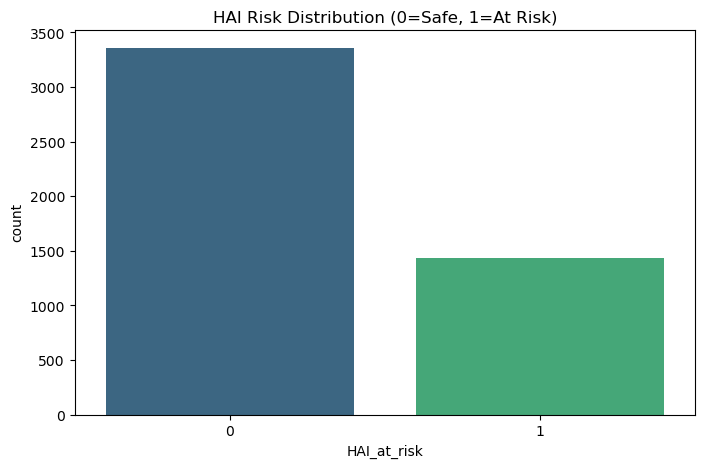

In [6]:
step_04 = importlib.import_module("04_data_analysis")

if 'master_data' in locals():
    step_04.run_eda()

# 05: Dynamic Feature Discovery and Selection

### 1. The Master Anchor
The process begins with the **Master Modeling Set** (4,789 facilities). By using this as the anchor, the script ensures that every potential predictor is linked to a facility with a known `HAI_at_risk` label.

### 2. Automated File Screening
Instead of manually selecting files, the logic scans all available datasets and applies a **Statistical Gatekeeper** to ensure high-quality inputs:
* **Identity Check:** A file must contain a `Facility ID` to be eligible for the join.
* **Population Overlap (50% Threshold):** Only files that contain data for at least 50% of the target facilities are processed. This automatically filters out noise from specialized datasets or state-level summaries that do not provide enough context for the whole population.

### 3. Structural Reshaping (Long-to-Wide)
CMS data is natively stored in a "Long" format where each measurement occupies a row. Machine learning requires "Wide" data where each row is a unique observation (hospital) and each column is a feature (predictor).
* **Numeric Identification:** The script locates the specific numeric measurement column (e.g., `Score`, `Value`, or `HCAHPS Linear Mean Score`).
* **Pivoting:** The `Measure ID` is transformed into a column header, and the numeric result becomes the cell value. 

### 4. Density-Based Feature Selection
To prevent the model from overfitting on sparse data or "learning from noise," a **Sparsity Filter** is applied to the individual columns:
* If a specific measure (e.g., `MORT_30_PN`) is missing for more than 50% of the hospitals in the modeling set, that feature is discarded.
* This ensures the resulting features are robust, high-density predictors that exist across the majority of the population.

### 5. Final Synthesis and Imputation
The disparate data points—ranging from clinical outcomes to patient satisfaction—are merged via a **Left Join**:
* **Integrity:** The 4,789 facilities are preserved as the primary population.
* **Model Readiness:** Remaining missing values are imputed using the **column median**. This provides a stable baseline for algorithms like XGBoost or Random Forest, ensuring that the "Predictive Drivers" are derived from the central tendency of the evidence.

In [7]:
step_05 = importlib.import_module("05_feature_identification")

if 'raw_datasets' in locals():
    # We pass the raw_datasets dictionary we loaded in Step 01
    final_df = step_05.mine_features(raw_datasets)
    display(final_df.head())

Targeting predictors for 4789 facilities...
[DATA DISCOVERED] Complications_and_Deaths-Hospital: Added 16 features.
[DATA DISCOVERED] Healthcare_Associated_Infections-Hospital: Added 23 features.
[DATA DISCOVERED] HOSPITAL_QUARTERLY_MSPB_6_DECIMALS: Added 1 features.
[DATA DISCOVERED] Medicare_Hospital_Spending_Per_Patient-Hospital: Added 1 features.
[DATA DISCOVERED] Outpatient_Imaging_Efficiency-Hospital: Added 2 features.
[DATA DISCOVERED] PATIENT_REPORTED_OUTCOMES_FACILITY: Added 1 features.
[DATA DISCOVERED] Timely_and_Effective_Care-Hospital: Added 12 features.
[DATA DISCOVERED] Unplanned_Hospital_Visits-Hospital: Added 8 features.
------------------------------
[SUCCESS] Final Feature Set Shape: (4789, 69)


,Facility ID,HAI_at_risk,Hospital Type,Hospital Ownership,Hospital overall rating,Hybrid_HWM,MORT_30_COPD,MORT_30_HF,MORT_30_PN,MORT_30_STK,...,SEV_SEP_3HR,SEV_SEP_6HR,EDAC_30_HF,EDAC_30_PN,Hybrid_HWR,OP_32,OP_36,READM_30_COPD,READM_30_HF,READM_30_PN
0,010001,0,Acute Care Hospitals,Government - Hospital District or Authority,4,4.5,9.4,10.2,18.4,13.5,...,78.0,97.0,-1.1,17.4,15.1,12.7,1.1,18.0,20.1,16.0
1,010005,1,Acute Care Hospitals,Government - Hospital District or Authority,3,4.6,8.9,14.1,21.2,12.9,...,85.0,99.0,12.2,-17.2,13.3,13.0,0.9,17.1,19.8,13.9
2,010006,0,Acute Care Hospitals,Proprietary,2,5.2,8.7,12.5,19.6,12.4,...,78.0,96.0,-4.7,-0.9,15.9,11.1,1.2,19.1,19.5,15.7
3,010007,0,Acute Care Hospitals,Voluntary non-profit - Private,1,4.8,11.2,13.4,25.4,13.1,...,62.0,94.0,77.9,29.8,15.4,12.5,1.0,18.6,20.9,16.5
4,010008,0,Acute Care Hospitals,Proprietary,Not Available,4.3,8.7,11.5,15.0,13.1,...,81.0,94.0,2.6,-8.9,14.7,12.7,1.0,18.1,19.6,16.0


## 6. Log Regression
Blurb

In [8]:
# run 06 .py log regression and save model

## 7. Rand Forst

In [9]:
# 07

# Meeting Discussion 3/13/26

**Which Metrics to Use**

- Not accuracy because of the class imbalance
- ROC-AUC, Precision-Recall curve, Weighted and macro F1 score, Matthews Correlation Coefficient, confusion

**Reproducibility and Splits**

- Put this in the ipynb 
- tonight's score as random seed
- StandardScaler

**Cross-Validation**
- 5 fold CV with stratified sampling and shuffling
- tune hyperparameters and threshold

**Class Imbalance**
- Class weights, smote with additional guardrails

**Data Cleaning**
- Punt handling string variable and missing data until we decide which features we want to include
- May go back to our original data set